In [1]:
from test.helpers import get_bqp, get_harmonic_oscillator

import jax.numpy as jnp
import jax.random as jrandom
import matplotlib.pyplot as plt
from diffrax import diffeqsolve, SaveAt
from diffrax.solver.foster_srk import FosterSRK
from jax import config


config.update("jax_enable_x64", True)
jnp.set_printoptions(precision=4, suppress=True)


# Plotting
def draw_order(hs, errs):
    plt.plot(1 / hs, errs)
    plt.yscale("log")
    plt.xscale("log")
    pretty_hs = ["{0:0.4f}".format(h) for h in hs]
    plt.xticks(ticks=1 / hs, labels=pretty_hs)
    plt.ylabel("RMS error")
    plt.xlabel("step size")
    plt.show()
    slope, _ = jnp.polyfit(jnp.log(hs), jnp.log(errs), 1)
    print(f"Order of convergence: {slope:.4f}")


def plot_sol(sol):
    plt.plot(sol.ts, sol.ys[0], label="x")
    plt.plot(sol.ts, sol.ys[1], label="v")
    plt.legend()
    plt.show()


dtype = jnp.float64
key = jrandom.PRNGKey(2)
num_samples = 100
keys = jrandom.split(jrandom.PRNGKey(5678), num=num_samples)
hs1 = jnp.power(2.0, jnp.arange(-3, -8, -1, dtype=dtype))


def get_dtype(x):
    if type(x) in [int, float, str]:
        return type(x)
    else:
        return jnp.dtype(x)


t0, t1 = 0.3, 15
saveat = SaveAt(ts=jnp.linspace(t0, t1, 1000))
dt0 = 0.1

t0_typed, t1_typed = dtype(0.3), dtype(15)
saveat_typed = SaveAt(ts=jnp.linspace(t0, t1, 1000, dtype=dtype))
dt0_typed = dtype(0.1)

hosc = get_harmonic_oscillator(0.3, 15.0, dtype=dtype)
terms_hosc = hosc.get_terms(hosc.get_bm(key, levy_area="space-time", tol=2**-10))
hosc_short = get_harmonic_oscillator(0.3, 5.1, dtype=dtype)

bqp = get_bqp(0.3, 15.0, dtype=dtype)
terms_bqp = bqp.get_terms(bqp.get_bm(key, levy_area="space-time", tol=2**-10))
bqp_short = get_bqp(0.3, 5.1, dtype=dtype)

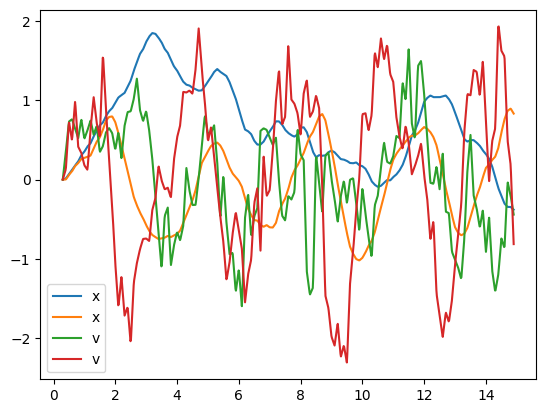

In [2]:
solFosSRK = diffeqsolve(
    terms_hosc, FosterSRK(), t0, t1, dt0=dt0, y0=hosc.y0, args=hosc.args, saveat=saveat
)
plot_sol(solFosSRK)